#Glocose level prediction project
This notebook focuses on predicting glucose levels using health-related features from the Framingham dataset.
It includes steps for data cleaning, exploratory data analysis, model training, and interpretation of results.


In [87]:
#importing required libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score,ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler

In [ ]:
df=pd.read_csv('framingham.csv')
print(df.head())
print('Shape of datset : ',df.shape)

   male  age  education  currentSmoker  cigsPerDay  BPMeds  prevalentStroke  \
0     1   39        4.0              0         0.0     0.0                0   
1     0   46        2.0              0         0.0     0.0                0   
2     1   48        1.0              1        20.0     0.0                0   
3     0   61        3.0              1        30.0     0.0                0   
4     0   46        3.0              1        23.0     0.0                0   

   prevalentHyp  diabetes  totChol  sysBP  diaBP    BMI  heartRate  glucose  \
0             0         0    195.0  106.0   70.0  26.97       80.0     77.0   
1             0         0    250.0  121.0   81.0  28.73       95.0     76.0   
2             0         0    245.0  127.5   80.0  25.34       75.0     70.0   
3             1         0    225.0  150.0   95.0  28.58       65.0    103.0   
4             0         0    285.0  130.0   84.0  23.10       85.0     85.0   

   TenYearCHD  
0           0  
1           0  
2 

In [104]:
print(df.describe())
print(df.info())

              male          age    education  currentSmoker   cigsPerDay  \
count  3852.000000  3852.000000  3852.000000    3852.000000  3852.000000   
mean      0.442627    49.638629     1.952752       0.490654     8.923157   
std       0.496762     8.597086     1.020613       0.499978    11.897852   
min       0.000000    32.000000     1.000000       0.000000     0.000000   
25%       0.000000    42.000000     1.000000       0.000000     0.000000   
50%       0.000000    49.000000     2.000000       0.000000     0.000000   
75%       1.000000    57.000000     3.000000       1.000000    20.000000   
max       1.000000    70.000000     4.000000       1.000000    70.000000   

            BPMeds  prevalentStroke  prevalentHyp     diabetes      totChol  \
count  3852.000000      3852.000000   3852.000000  3852.000000  3852.000000   
mean      0.029595         0.006231      0.312825     0.027259   236.977095   
std       0.169489         0.078698      0.463704     0.162857    44.713892   

In [ ]:
df=df.dropna(subset=['glucose'])
df['education']=df['education'].fillna(df['education'].mode()[0])
df['cigsPerDay']=df['cigsPerDay'].fillna(df['cigsPerDay'].mode()[0])
df['BPMeds']=df['BPMeds'].fillna(df['BPMeds'].mode()[0])
df['BMI']=df['BMI'].fillna(df['BMI'].mode()[0])
df['totChol']=df['totChol'].fillna(df['totChol'].mean())
df['heartRate']=df['heartRate'].fillna(df['heartRate'].mean())

In [ ]:
def label_glucose(g):
  if g < 100:
    return 0 #normal
  elif g <= 126:
    return 1 #pre-diabetic
  else :
    return 2 #diabetic
df['glucose_cat'] = df['glucose'].apply(label_glucose)
X=df.drop(columns=['glucose','glucose_cat'])
y=df['glucose_cat']

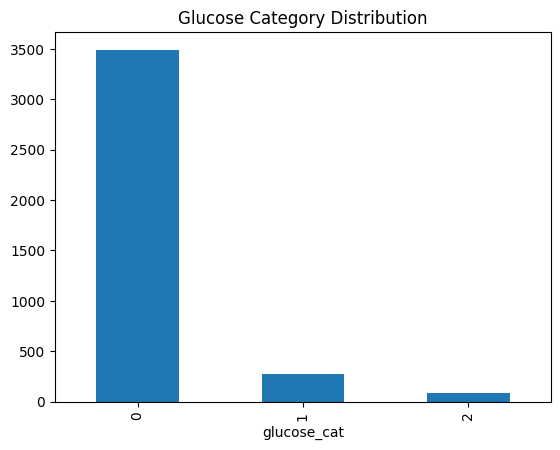

In [100]:
#class distribution
df['glucose_cat'].value_counts().plot(kind='bar')
plt.title("Glucose Category Distribution")
plt.show()

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test =scaler.transform(X_test)

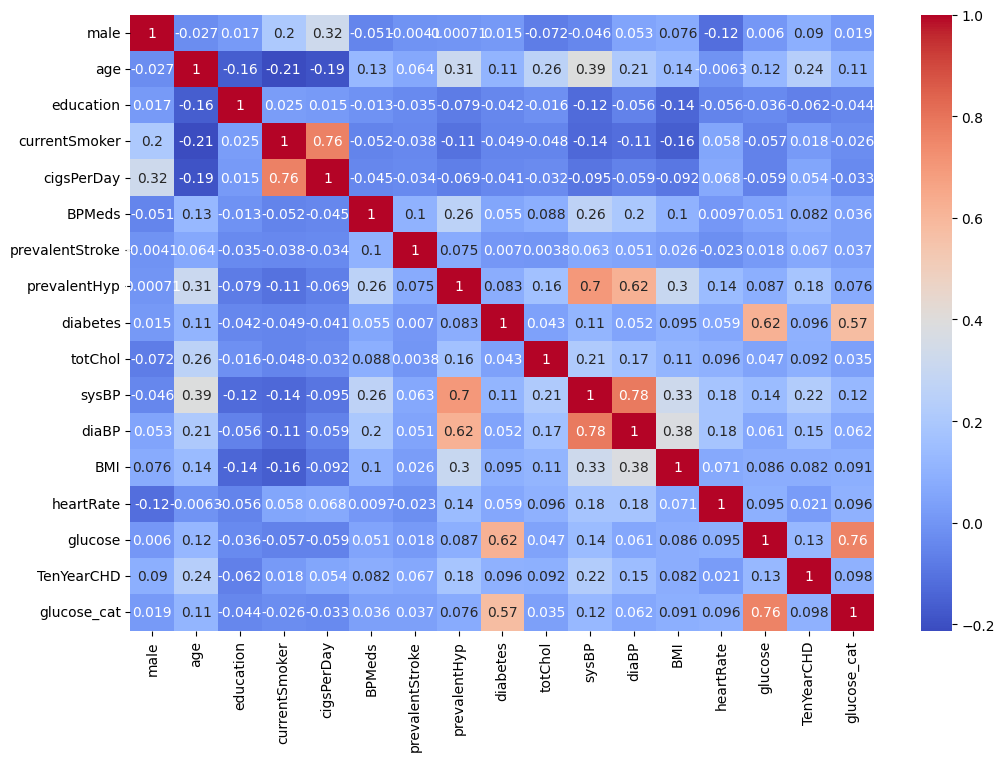

In [ ]:
corr = df.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

LR Accuracy =  0.6251621271076524
LR Precision =  0.8803400928149936
LR Recall =  0.6251621271076524
LR F1 Score =  0.7172554219584419
LR Classification report : 
               precision    recall  f1-score   support

           0       0.95      0.64      0.76       707
           1       0.07      0.35      0.11        48
           2       0.35      0.81      0.49        16

    accuracy                           0.63       771
   macro avg       0.46      0.60      0.46       771
weighted avg       0.88      0.63      0.72       771



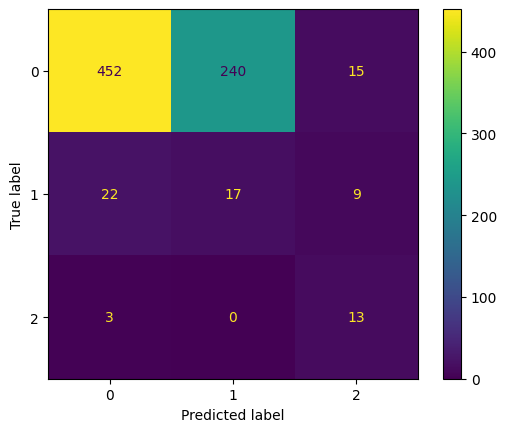

In [103]:
from sklearn.linear_model import LogisticRegression
LR=LogisticRegression(class_weight='balanced')
LR.fit(X_train,y_train)
LR_pred=LR.predict(X_test)
print('LR Accuracy = ',accuracy_score(y_test,LR_pred))
print('LR Precision = ',precision_score(y_test,LR_pred,average='weighted'))
print('LR Recall = ',recall_score(y_test,LR_pred,average='weighted'))
print('LR F1 Score = ',f1_score(y_test,LR_pred,average='weighted'))
print('LR Classification report : \n',classification_report(y_test,LR_pred))
ConfusionMatrixDisplay.from_predictions(y_test,LR_pred)
plt.show()

dtc Accuracy =  0.8197146562905318
dtc Precision =  0.8707468878209864
dtc Recall =  0.8197146562905318
dtc F1 Score =  0.8432232068093672
dtc Classification report : 
               precision    recall  f1-score   support

           0       0.94      0.87      0.90       707
           1       0.10      0.19      0.13        48
           2       0.22      0.31      0.26        16

    accuracy                           0.82       771
   macro avg       0.42      0.46      0.43       771
weighted avg       0.87      0.82      0.84       771



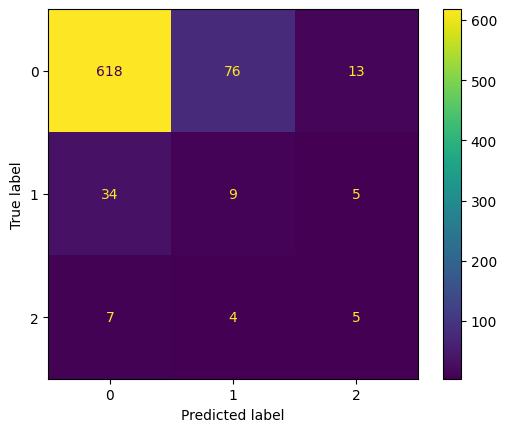

In [92]:
from sklearn.tree import DecisionTreeClassifier
dtc=DecisionTreeClassifier(random_state=42)
dtc.fit(X_train,y_train)
dtc_pred=dtc.predict(X_test)
print('dtc Accuracy = ',accuracy_score(y_test,dtc_pred))
print('dtc Precision = ',precision_score(y_test,dtc_pred,average='weighted'))
print('dtc Recall = ',recall_score(y_test,dtc_pred,average='weighted'))
print('dtc F1 Score = ',f1_score(y_test,dtc_pred,average='weighted'))
print('dtc Classification report : \n',classification_report(y_test,dtc_pred))
ConfusionMatrixDisplay.from_predictions(y_test,dtc_pred)
plt.show()

rf Accuracy =  0.9195849546044098
rf Precision =  0.8692137861890175
rf Recall =  0.9195849546044098
rf F1 Score =  0.8931486398618457
rf Classification report : 
               precision    recall  f1-score   support

           0       0.94      0.99      0.96       707
           1       0.00      0.00      0.00        48
           2       0.37      0.62      0.47        16

    accuracy                           0.92       771
   macro avg       0.44      0.54      0.48       771
weighted avg       0.87      0.92      0.89       771



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

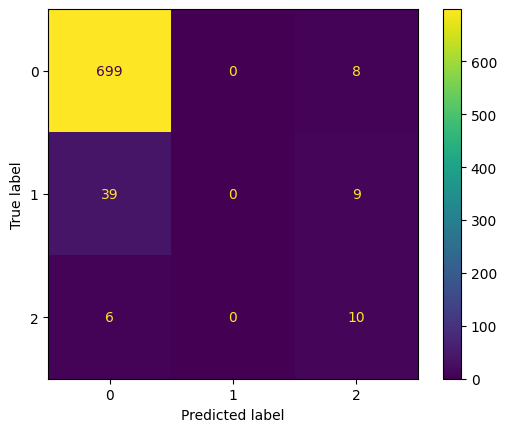

In [93]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(n_estimators=500,random_state=42,class_weight='balanced')
rf.fit(X_train,y_train)
rf_pred=rf.predict(X_test)
print('rf Accuracy = ',accuracy_score(y_test,rf_pred))
print('rf Precision = ',precision_score(y_test,rf_pred,average='weighted'))
print('rf Recall = ',recall_score(y_test,rf_pred,average='weighted'))
print('rf F1 Score = ',f1_score(y_test,rf_pred,average='weighted'))
print('rf Classification report : \n',classification_report(y_test,rf_pred))
ConfusionMatrixDisplay.from_predictions(y_test,rf_pred)
plt.show()

<Axes: xlabel='Importance', ylabel='Features'>

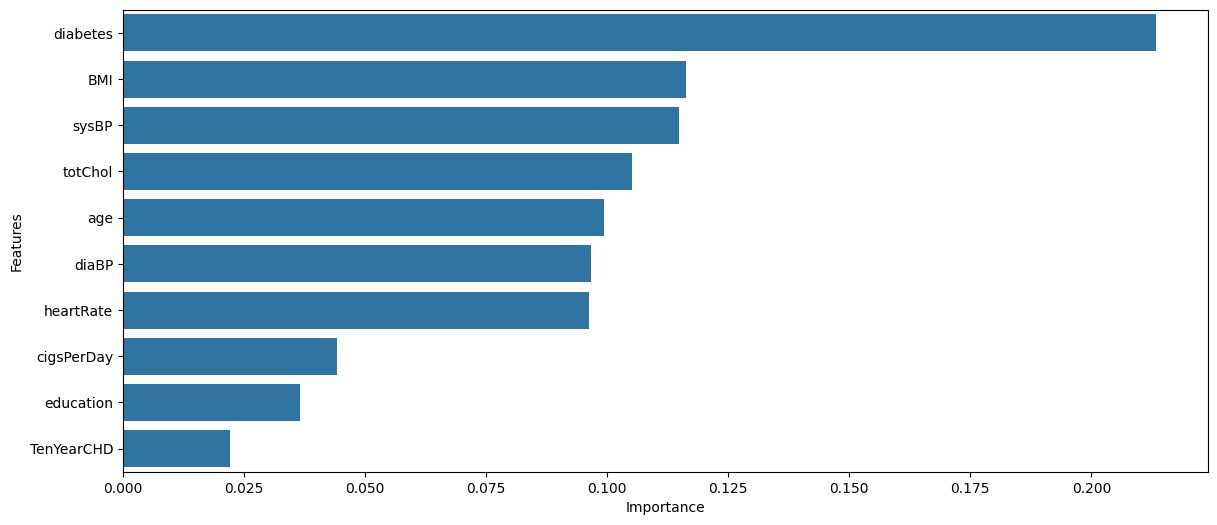

In [101]:
importance=pd.DataFrame({'Features':X.columns,'Importance':rf.feature_importances_})
importance=importance.sort_values(by='Importance',ascending=False).head(10)
plt.figure(figsize=(14,6))
sns.barplot(importance,x='Importance',y='Features')

nb Accuracy =  0.8884565499351491
nb Precision =  0.8759145681618951
nb Recall =  0.8884565499351491
nb F1 Score =  0.877187591691818
nb Classification report : 
               precision    recall  f1-score   support

           0       0.94      0.95      0.95       707
           1       0.12      0.02      0.04        48
           2       0.24      0.75      0.37        16

    accuracy                           0.89       771
   macro avg       0.44      0.57      0.45       771
weighted avg       0.88      0.89      0.88       771



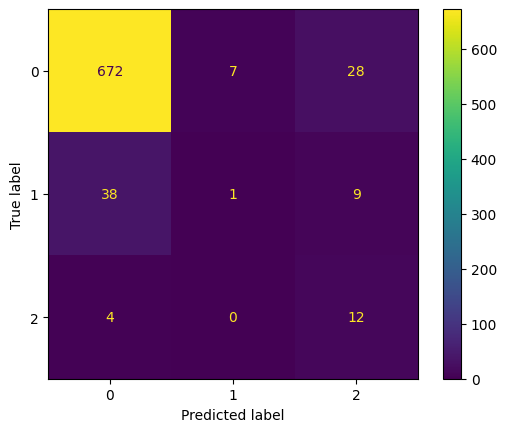

In [102]:
from sklearn.naive_bayes import GaussianNB
nb=GaussianNB()
nb.fit(X_train,y_train)
nb_pred=nb.predict(X_test)
print('nb Accuracy = ',accuracy_score(y_test,nb_pred))
print('nb Precision = ',precision_score(y_test,nb_pred,average='weighted'))
print('nb Recall = ',recall_score(y_test,nb_pred,average='weighted'))
print('nb F1 Score = ',f1_score(y_test,nb_pred,average='weighted'))
print('nb Classification report : \n',classification_report(y_test,nb_pred))
ConfusionMatrixDisplay.from_predictions(y_test,nb_pred)
plt.show()

xgb Accuracy =  0.9156939040207522
xgb Precision =  0.8625212791828794
xgb Recall =  0.9156939040207522
xgb F1 Score =  0.8790225949906442
xgb Classification report : 
               precision    recall  f1-score   support

           0       0.92      1.00      0.96       707
           1       0.33      0.02      0.04        48
           2       0.00      0.00      0.00        16

    accuracy                           0.92       771
   macro avg       0.42      0.34      0.33       771
weighted avg       0.86      0.92      0.88       771



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

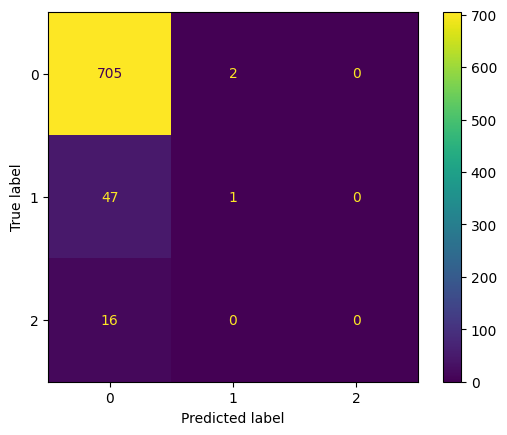

In [95]:
from xgboost import XGBClassifier
xgb=XGBClassifier()
xgb.fit(X_train,y_train)
xgb_pred=xgb.predict(X_test)
print('xgb Accuracy = ',accuracy_score(y_test,xgb_pred))
print('xgb Precision = ',precision_score(y_test,xgb_pred,average='weighted'))
print('xgb Recall = ',recall_score(y_test,xgb_pred,average='weighted'))
print('xgb F1 Score = ',f1_score(y_test,xgb_pred,average='weighted'))
print('xgb Classification report : \n',classification_report(y_test,xgb_pred))
ConfusionMatrixDisplay.from_predictions(y_test,xgb_pred)
plt.show()

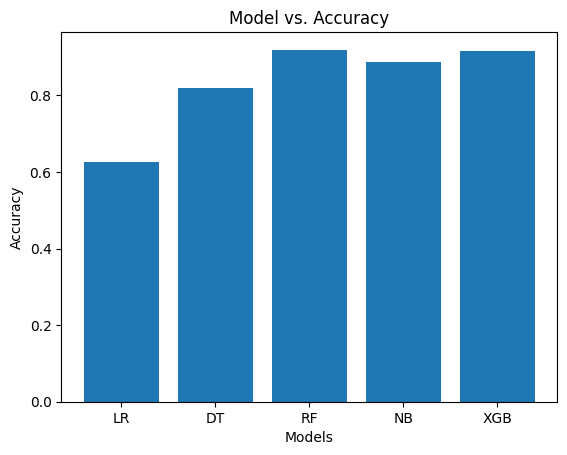

In [97]:
models = ['LR','DT','RF','NB','XGB']

acc = [
    accuracy_score(y_test, LR_pred),
    accuracy_score(y_test, dtc_pred),
    accuracy_score(y_test, rf_pred),
    accuracy_score(y_test, nb_pred),
    accuracy_score(y_test, xgb_pred)
]
plt.bar(models,acc)
plt.title('Model vs. Accuracy')
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.show()

In [99]:
results = pd.DataFrame({
    'Model':['LR','DT','RF','NB','XGB'],
    'Accuracy' : [
    accuracy_score(y_test, LR_pred),
    accuracy_score(y_test, dtc_pred),
    accuracy_score(y_test, rf_pred),
    accuracy_score(y_test, nb_pred),
    accuracy_score(y_test, xgb_pred)
],
    'F1 Score':[f1_score(y_test, LR_pred,average='weighted'),
    f1_score(y_test, dtc_pred,average='weighted'),
    f1_score(y_test, rf_pred,average='weighted'),
   f1_score(y_test, nb_pred,average='weighted'),
    f1_score(y_test, xgb_pred,average='weighted')
]
})

print(results)

  Model  Accuracy  F1 Score
0    LR  0.625162  0.717255
1    DT  0.819715  0.843223
2    RF  0.919585  0.893149
3    NB  0.888457  0.877188
4   XGB  0.915694  0.879023


#Conclusion
This project successfully classified patients into Normal, Pre-Diabetic, and Diabetic categories using machine learning algorithms. Among the tested models, Random Forest and XGBoost achieved the best performance. The results highlight the importance of factors such as diabetes status, BMI, age, and blood pressure in predicting glucose categories and demonstrate the potential of ML in supporting early healthcare decision-making.